# Task 2 #

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch
from torch.utils.data import DataLoader
from datetime import datetime
import numpy as np
import pandas as pd

# General Preprocessing utilities
from utilities.preprocessing import (DataPreprocessor, clip_feature_values)

# Task 2.3a specific utilities
from Scripts.Task_2_3a import (
    SimpleTransformer,
    load_and_preprocess_dataset,
    create_dataloader
)

# Task 2.3b specific utilities 
from Scripts.Task_2_3b import (
    TripletTransformer,       
    load_raw_to_grid,
    preprocess_pipeline,
    dataframe_to_triplets,
    PhysioNetDataset,
    collate_fn
)
# Training pipeline functions 
from utilities.training_functions import (
    set_seed,
    run_training_pipeline,
    run_final_test,
)
# Plotting and reporting 
from utilities.plotting import (
    plot_training_results,
    report_test_results,
)
# Directory management 
from utilities.dir_manager import (
    clean_checkpoint_dir,
)

In [23]:
# Enforce reproducibility before any execution logic
SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rnd_generator = torch.Generator()
rnd_generator.manual_seed(SEED)

## Task 2.3 ##

### Task 2.3a ###

In [ ]:
PREPROCESSED_DIR = "output/preprocessed_imputed_datasets"
base_dir_task_2_3a = "model_checkpoints/task_2_3a"
CLIP = 5.0
EPOCHS = 4
BATCH_SIZE = 64


df_a, FEATURE_COLS = load_and_preprocess_dataset(f"{PREPROCESSED_DIR}/preprocessed_set_a.parquet", "Set A", CLIP)
df_b, _ = load_and_preprocess_dataset(f"{PREPROCESSED_DIR}/preprocessed_set_b.parquet", "Set B", CLIP)
df_c, _ = load_and_preprocess_dataset(f"{PREPROCESSED_DIR}/preprocessed_set_c.parquet", "Set C", CLIP)


Data clipped... for 52 features.
[Set A] No missing values found. (196000 rows)
[Set A] ✓ All 4000 patients have exactly 49 rows.
Data clipped... for 52 features.
[Set B] No missing values found. (196000 rows)
[Set B] ✓ All 4000 patients have exactly 49 rows.
Data clipped... for 52 features.
[Set C] No missing values found. (196000 rows)
[Set C] ✓ All 4000 patients have exactly 49 rows.


In [25]:
train_loader = create_dataloader(df_a, FEATURE_COLS, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = create_dataloader(df_b, FEATURE_COLS, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = create_dataloader(df_c, FEATURE_COLS, batch_size=BATCH_SIZE, shuffle=False)

print(f"Created train_loader: {len(train_loader)} batches")
print(f"Created val_loader:   {len(val_loader)} batches")
print(f"Created test_loader:  {len(test_loader)} batches")

Created train_loader: 63 batches
Created val_loader:   63 batches
Created test_loader:  63 batches


In [26]:
# Model instantiation
NUM_FEATURES  = len(FEATURE_COLS)
D_MODEL       = 64
NHEAD         = 1
NUM_LAYERS    = 2
DIM_FFORWARD  = 128
DROPOUT       = 0.1

model = SimpleTransformer(
    num_features    = NUM_FEATURES,
    d_model         = D_MODEL,
    nhead           = NHEAD,
    num_layers      = NUM_LAYERS,
    dim_feedforward = DIM_FFORWARD,
    dropout         = DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=2
    )


/Users/lorenzofrigoli/Documents/UZH/MSc/ML_for_HC/ML4HC_Project1/utilities/Task2_3a.py:65: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [27]:
results = run_training_pipeline(
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    save_dir=base_dir_task_2_3a,
    epochs=EPOCHS,
    scheduler=scheduler,
    data_format="dense"
    )


Epoch 01 | Train Loss: 0.3701 | Val Loss: 0.3638 | Val AuROC: 0.7669 | Val AuPRC: 0.3702
  >> Checkpoint synced to: model_checkpoints/task_2_3a/run_20260331_152334
  * Best model updated (AuPRC: 0.3702)
Epoch 02 | Train Loss: 0.3236 | Val Loss: 0.3457 | Val AuROC: 0.7950 | Val AuPRC: 0.3880
  >> Checkpoint synced to: model_checkpoints/task_2_3a/run_20260331_152334
  * Best model updated (AuPRC: 0.3880)
Epoch 03 | Train Loss: 0.3013 | Val Loss: 0.3464 | Val AuROC: 0.7950 | Val AuPRC: 0.3888
  >> Checkpoint synced to: model_checkpoints/task_2_3a/run_20260331_152334
  * Best model updated (AuPRC: 0.3888)
Epoch 04 | Train Loss: 0.2818 | Val Loss: 0.3361 | Val AuROC: 0.8106 | Val AuPRC: 0.4076
  >> Checkpoint synced to: model_checkpoints/task_2_3a/run_20260331_152334
  * Best model updated (AuPRC: 0.4076)


In [28]:
current_save_dir_2_3a = results["save_dir"]
current_run_name_2_3a = results["run_name"]

Cleaned plots saved to: model_checkpoints/task_2_3a/run_20260331_152334/training_curves.png


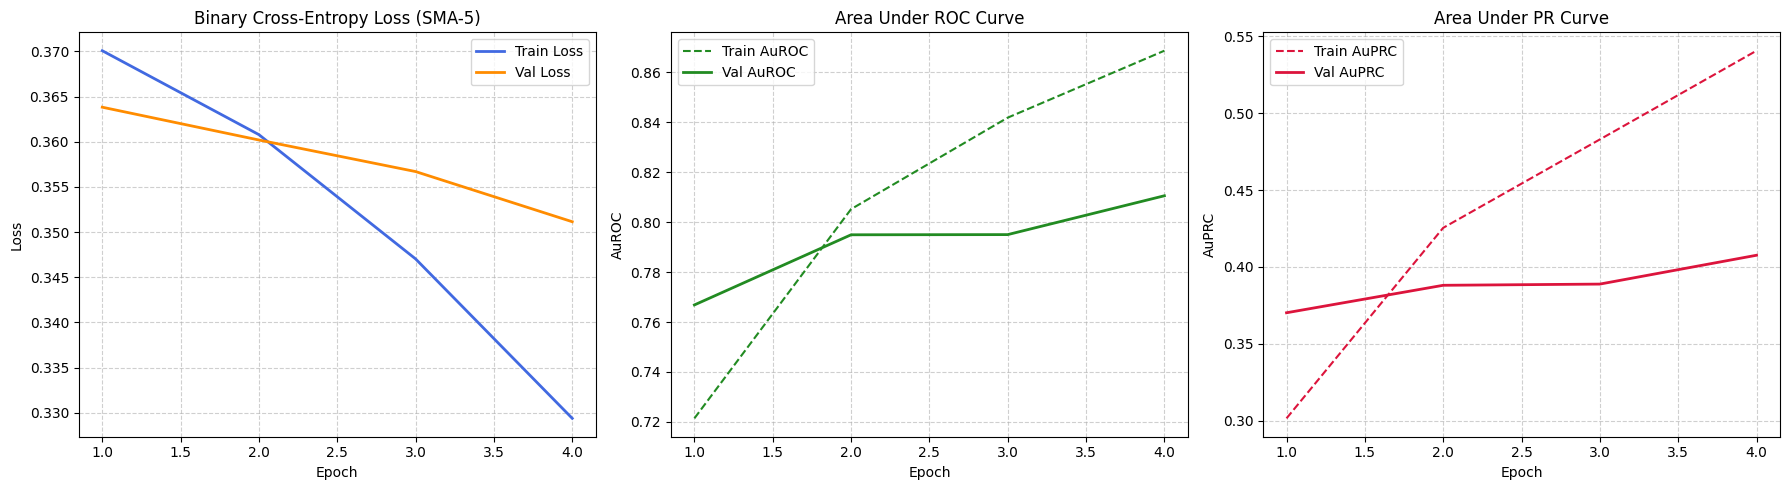

In [40]:
plot_training_results(results["history"], save_path=current_save_dir_2_3a / "training_curves.png")

In [29]:
test_results = run_final_test(
    model=model,
    test_loader=test_loader,
    checkpoint_path=f"{current_save_dir_2_3a}/best_model.pt",
    device=device,
    data_format="dense"
)

report_test_results(test_results, model_name="Simple Transformer (Task 2.3a)")


Loading best model weights from: model_checkpoints/task_2_3a/run_20260331_152334/best_model.pt
Starting final evaluation on Set C...

FINAL TEST RESULTS (SET C)
AuROC: 0.8005
AuPRC: 0.4194
Loss:  0.3481

 FINAL PERFORMANCE REPORT: Simple Transformer (Task 2.3a)
Metric          | Value     
----------------------------
AuROC           | 0.8005
AuPRC           | 0.4194
Test Loss       | 0.3481
---------------------------------------------
Simple Transformer (Task 2.3a) & 0.8005 & 0.4194 & 0.3481 \\



In [30]:
# Clean checkpoint directory
clean_checkpoint_dir(base_dir=base_dir_task_2_3a, keep_run_name=current_run_name_2_3a)

Cleaning directory: model_checkpoints/task_2_3a
Keeping only: run_20260331_152334
  [Preserved] run_20260331_152334 (Best Model)
  [Deleted] run_20260329_164728

Cleanup complete. Removed 1 old run directories.


### Task 2.3b ###

In [4]:
# Initialization for model and hyperparameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir_task_2_3b = "model_checkpoints/task_2_3b"
epochs = 2
CLIP = 5.0
SEED = 42
set_seed(SEED)
rnd_generator = torch.Generator()
rnd_generator.manual_seed(SEED)
BATCH_SIZE = 128

model = TripletTransformer(
    d_model=64,
    nhead=2,
    num_layers=3,
    d_time_emb=4,
    dim_feedforward=176,
    dropout=0.1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=2
    )

/Users/lorenzofrigoli/Documents/UZH/MSc/ML_for_HC/ML4HC_Project1/utilities/models.py:164: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [5]:
raw_a, labels_a = load_raw_to_grid('ml4h_data/p1/set-a/', 'ml4h_data/p1/Outcomes-a.txt')
raw_b, labels_b = load_raw_to_grid('ml4h_data/p1/set-b/', 'ml4h_data/p1/Outcomes-b.txt')
raw_c, labels_c = load_raw_to_grid('ml4h_data/p1/set-c/', 'ml4h_data/p1/Outcomes-c.txt')


# Instantiate DataPreprocessor 
processor = DataPreprocessor(impute_outliers=True, impute_missing=False, encode_cat=True)

# preprocess data
scaled_a, valid_cols = preprocess_pipeline(raw_a, processor, is_train=True, clip_val=CLIP)
scaled_b, _ = preprocess_pipeline(raw_b, processor, is_train=False, clip_val=CLIP)
scaled_c, _ = preprocess_pipeline(raw_c, processor, is_train=False, clip_val=CLIP)

Data clipped... for 51 features.
Data clipped... for 51 features.
Data clipped... for 51 features.


In [6]:
# Create Loaders
train_triplets = dataframe_to_triplets(scaled_a, valid_cols)
train_loader = DataLoader(PhysioNetDataset(train_triplets, labels_a), 
                          batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, generator=rnd_generator)

val_triplets = dataframe_to_triplets(scaled_b, valid_cols)
val_loader = DataLoader(PhysioNetDataset(val_triplets, labels_b), 
                        batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, generator=rnd_generator)
test_triplets = dataframe_to_triplets(scaled_c, valid_cols)
test_loader = DataLoader(PhysioNetDataset(test_triplets, labels_c), 
                         batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, generator=rnd_generator)

Converted DataFrame to 4000 patient sequences of triplets.
Converted DataFrame to 4000 patient sequences of triplets.
Converted DataFrame to 4000 patient sequences of triplets.


In [ ]:
# Train the Model
training_results = run_training_pipeline(
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    save_dir=base_dir_task_2_3b,
    epochs=epochs,
    data_format="triplet"
)

In [ ]:
current_save_dir_2_3b = training_results["save_dir"]
current_run_name_2_3b = training_results["run_name"]

Cleaned plots saved to: model_checkpoints/task_2_3b/run_20260331_152416/training_curves.png


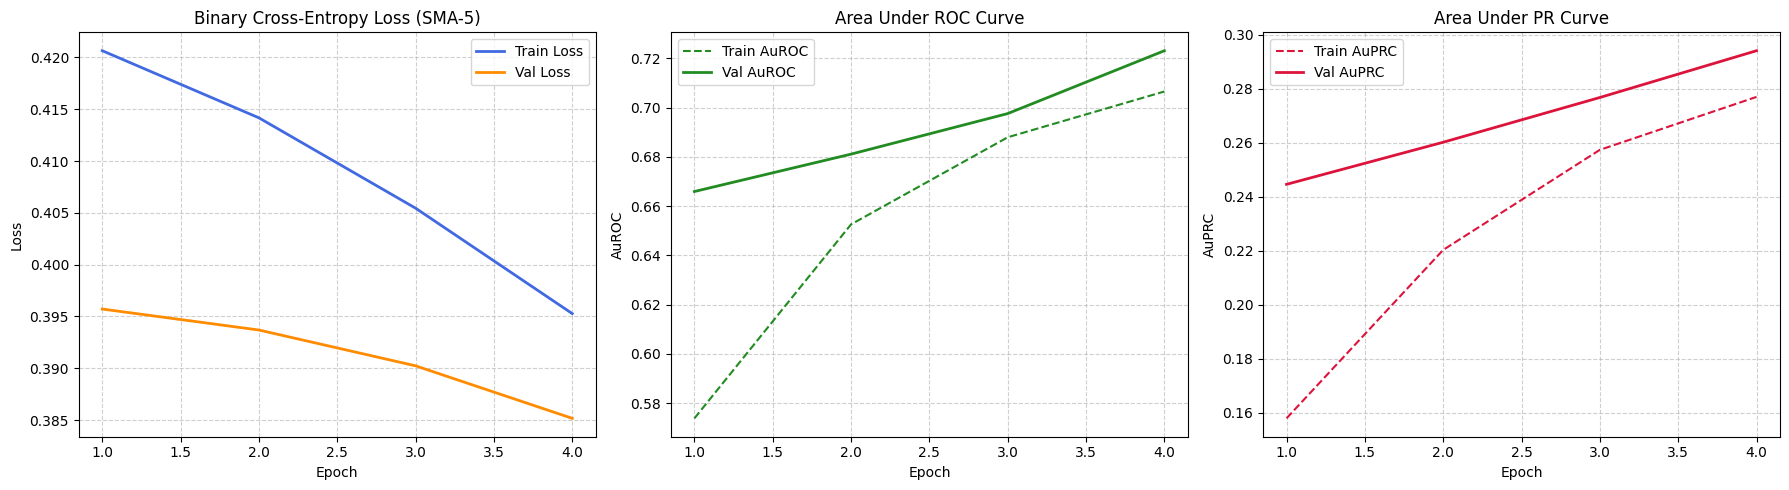

In [ ]:
# Plot Metrics
plot_training_results(training_results["history"], save_path=current_save_dir_2_3b / "training_curves.png")

In [ ]:
# Test on the Test Set
best_model_path = current_save_dir_2_3b / "best_model.pt"
test_results = run_final_test(
    model=model,
    test_loader=test_loader,
    checkpoint_path=str(best_model_path),
    device=device,
    data_format="triplet"
)


Loading best model weights from: model_checkpoints/task_2_3b/run_20260331_152416/best_model.pt
Starting final evaluation on Set C...

FINAL TEST RESULTS (SET C)
AuROC: 0.7181
AuPRC: 0.3016
Loss:  0.3788


In [ ]:
# Report the metric
report_test_results(test_results, model_name="Transformer (Task 2.3b)")


 FINAL PERFORMANCE REPORT: Transformer (Task 2.3b)
Metric          | Value     
----------------------------
AuROC           | 0.7181
AuPRC           | 0.3016
Test Loss       | 0.3788
---------------------------------------------
Transformer (Task 2.3b) & 0.7181 & 0.3016 & 0.3788 \\



In [ ]:

# Clean checkpoint directory
clean_checkpoint_dir(base_dir=base_dir_task_2_3b, keep_run_name=current_run_name_2_3b)

Cleaning directory: model_checkpoints/task_2_3b
Keeping only: run_20260331_152416
  [Preserved] run_20260331_152416 (Best Model)
  [Deleted] run_20260329_171043

Cleanup complete. Removed 1 old run directories.
